# 01 — Comma-separated text

The shape you already know: rows and columns, separated by commas. A server hands
you one and you turn it into a table.

Four ways to do the same fetch. The last is one line.

## 1. What we're fetching

```bash
https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv?analysed_sst%5B(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)%5D%5B(36.6):(36.6)%5D%5B(-122.2):(-122.2)%5D&.time=first&.lat=first&.lon=first
```

A URL is three things glued together:

```
https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv   <- where
?analysed_sst%5B...%5D%5B36.6...%5D%5B-122.2...%5D              <- what
&.time=first&.lat=first&.lon=first                                <- how to slice it
```

The part after `?` is a query string: `name=value` pairs joined by `&`. You have
written one before — every search box on the internet builds one. Square brackets
have to be written `%5B` and `%5D` so they survive the trip; that is all that
encoding is.

This particular one asks for one point in the ocean, every day in September 2019.

In [1]:
import io

import pandas as pd
import requests

SST_URL = (
    "https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv"
    "?analysed_sst%5B(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)%5D"
    "%5B(36.6):(36.6)%5D%5B(-122.2):(-122.2)%5D"
    "&.time=first&.lat=first&.lon=first"
)

r = requests.get(SST_URL, timeout=30)
r.raise_for_status()          # 4xx/5xx become an exception you can read
print(r.status_code, len(r.content), "bytes")
print()
print(r.text[:150])

200 1324 bytes

time,latitude,longitude,analysed_sst
UTC,degrees_north,degrees_east,degree_C
2019-09-01T09:00:00Z,36.6,-122.2,16.383
2019-09-02T09:00:00Z,36.6,-122.2,


## 2. The part that is annoying

`r.text` is a **string**, and pandas wants either a file path or a file-like object.
One line bridges them:

```python
io.StringIO(r.text)
```

That is the whole trick, and you will write it constantly.

In [2]:
df = pd.read_csv(io.StringIO(r.text), skiprows=[1])
print(df.shape, list(df.columns))
print(df.head(3).to_string(index=False))

(30, 4) ['time', 'latitude', 'longitude', 'analysed_sst']
                time  latitude  longitude  analysed_sst
2019-09-01T09:00:00Z      36.6     -122.2        16.383
2019-09-02T09:00:00Z      36.6     -122.2        15.747
2019-09-03T09:00:00Z      36.6     -122.2        15.595


## 3. What `skiprows` was for

Without it you get something wrong and nothing tells you:

```python
pd.read_csv(io.StringIO(r.text))
```

The first column would be full of the strings `"UTC"`, `"degrees_north"` and so on —
one row, one value, shifted by one. **No error. No warning.** Just a table where the
first data row is the file's units.

Look back at the raw text above. Line 1 is the names. Line 2 is the units. Line 3 is
the first real row. `skiprows=[1]` drops line 2 and leaves the rest correct.

This is the shape of most data problems you will ever have: **the data is fine, the
framing is not.** `skiprows` is the most common fix in this entire course.

In [3]:
naive = pd.read_csv(io.StringIO(r.text))          # the mistake
fixed = pd.read_csv(io.StringIO(r.text), skiprows=[1])   # the fix

print("without skiprows -- first row:")
print(naive.head(1).to_string(index=False))
print()
print("with skiprows -- first row:")
print(fixed.head(1).to_string(index=False))
print()
print(f"naive has {naive.analysed_sst.isna().sum()} missing temperatures, "
      f"fixed has {fixed.analysed_sst.isna().sum()}")

without skiprows -- first row:
time      latitude    longitude analysed_sst
 UTC degrees_north degrees_east     degree_C

with skiprows -- first row:
                time  latitude  longitude  analysed_sst
2019-09-01T09:00:00Z      36.6     -122.2        16.383

naive has 0 missing temperatures, fixed has 0


## 4. One line, with DuckDB

Everything above — the request, the text, the `StringIO`, the `skiprows` — exists
because a library is fussy about what it accepts.

DuckDB is not. Give it a URL and a SQL query and it does the rest:

```python
duckdb.sql("SELECT * FROM read_csv_auto('<url>')")
```

No download, no parse, no cache. It is not in your standard stack yet, which is why
it is last, but it is the punchline of the next three notebooks.

In [4]:
import duckdb

rows = duckdb.sql(f"""
    SELECT time::TIMESTAMP AS time,
           analysed_sst::DOUBLE AS analysed_sst
    FROM read_csv_auto('{SST_URL}')
    WHERE time <> 'UTC'          -- drop the units row, which is still a data row
    ORDER BY time
""").df()                       # .df() to get a pandas DataFrame back

print(rows.shape, dict(rows.dtypes.astype(str)))
print(rows.head(3).to_string(index=False))

(30, 2) {'time': 'datetime64[us]', 'analysed_sst': 'float64'}
               time  analysed_sst
2019-09-01 09:00:00        16.383
2019-09-02 09:00:00        15.747
2019-09-03 09:00:00        15.595


The same numbers, and notice what DuckDB did and did not do for you.

It read the **header** correctly with no help. It did **not** remove the units line —
that is still sitting in the table as a row of data, which is why `time` came back as
text and `analysed_sst` came back as text, and why the arithmetic failed until you
cast them.

`pandas` failed differently: it trusted your `skiprows` and got the shift right by
accident. DuckDB got the header right and left the rest for you to ask for in SQL.

**Neither tool is smarter. They guess differently, and here they each got half of it.**
That is worth more than a rule about which to use, because it is the rule: look at what
you got before you compute with it.

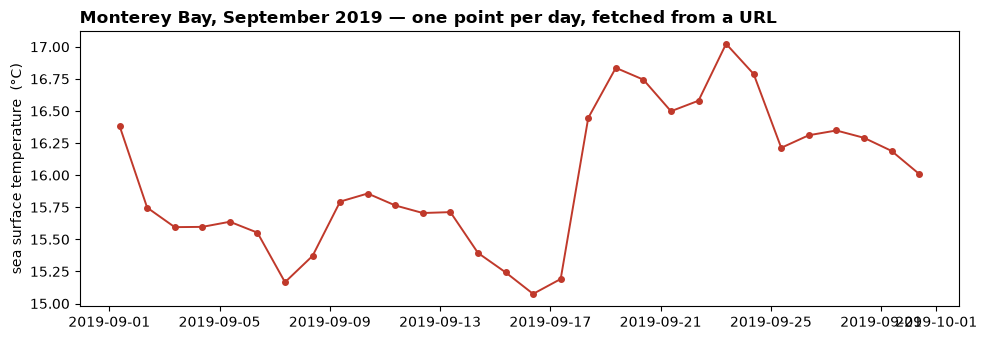

  15.1 to 17.0 °C, mean 16.0
  15-17 °C is right for a California coast in September: upwelling pulls cold
  water up from depth. If you had got 22 °C, something was wrong with the fetch.


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rows.time, rows.analysed_sst, marker="o", ms=4, lw=1.4, color="#c0392b")
ax.set_ylabel("sea surface temperature  (°C)")
ax.set_title("Monterey Bay, September 2019 — one point per day, fetched from a URL",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"  {rows.analysed_sst.min():.1f} to {rows.analysed_sst.max():.1f} °C, "
      f"mean {rows.analysed_sst.mean():.1f}")
print("  15-17 °C is right for a California coast in September: upwelling pulls cold")
print("  water up from depth. If you had got 22 °C, something was wrong with the fetch.")